In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

from statsmodels.api import OLS
import sklearn.model_selection as skm
from ISLP.models import ModelSpec as MS

from ISLP.models import Stepwise
from ISLP.models import sklearn_selection_path

from plots import *
import seaborn as sns

In [2]:
data_fpath = Path('stable_scores.csv')
df = pd.read_csv(data_fpath)

df_ps_cols = pd.read_csv('df_ps_col_labels.csv')
ps_cols = df_ps_cols['ps'].values
ps_cols_labels = dict(zip(df_ps_cols['ps'], df_ps_cols['label']))

figdir = Path('figs')
figdir.mkdir(parents=True, exist_ok=True)


In [3]:
def forward_stepwise_selection(X, Y):
    strategy = Stepwise.fixed_steps(design, len(design.terms), direction='forward')
    full_path = sklearn_selection_path(OLS, strategy, scoring='r2')
    full_path.fit(X, Y)
    Yhat_in = full_path.predict(X)

    # get feature selection order
    feat_order = []
    for feats, _, _, in full_path.models_[1:]:
        feats = [feat.name for feat in feats]
        new_feats = [x for x in feats if x not in feat_order]
        assert len(new_feats) == 1
        feat_order.extend(new_feats)
    feat_order

    return full_path, Yhat_in, feat_order


In [4]:
def r2_metric(Y_pred, Y_true):
    return np.apply_along_axis(lambda x: r2_score(Y_true, x), 0, Y_pred)


def plot_kfold_cv(X, Y, Yhat_in, full_path, ax):
    insample_mape = r2_metric(Yhat_in, Y[:,None])
    n_steps = insample_mape.shape[0]
    
    K = 5
    kfold = skm.KFold(K, random_state=5, shuffle=True)
    Yhat_cv = skm.cross_val_predict(full_path, X, Y, cv=kfold)
    cv_mse = []
    for _ , test_idx in kfold.split(Y):
        errors = r2_metric(Yhat_cv[test_idx], Y[test_idx,None])
        cv_mse.append(errors)
    cv_mse = np.array(cv_mse).T

    ax.errorbar(
        np.arange(1,n_steps),
        cv_mse.mean(1)[1:],
        cv_mse.std(1)[1:] / np.sqrt(K),
        #label='Cross -validated',
        fmt='.',
        c=cp[0],
        clip_on=False,
        )
    
    ax.set_ylabel('R²', fontdict={'weight':'semibold'})
    ax.set_xlabel('Number of selected features', fontdict={'weight':'semibold'})
    ax.set_xticks(np.arange(n_steps)[1::2])
    ax.set_ylim(0, 1)

    return cv_mse.mean(1)[1:]


Full dataset (n = 180)
01 - 62.9% variance - ps_y_balance
02 - 74.9% variance - ps_sls_ec
03 - 81.6% variance - ps_gait_bwd
04 - 85.1% variance - ps_gait_pivot
05 - 88.1% variance - ps_sls_rtt_ec
06 - 91.0% variance - ps_gait_tandem
07 - 93.5% variance - ps_gait_fast
08 - 95.0% variance - ps_jump
09 - 95.2% variance - ps_gait_ec
10 - 96.0% variance - ps_5tsts
11 - 96.8% variance - ps_march
12 - 97.4% variance - ps_gait
13 - 98.3% variance - ps_tandem
14 - 98.9% variance - ps_rtt
15 - 99.2% variance - ps_semi_tandem
16 - 99.5% variance - ps_frt
17 - 99.8% variance - ps_sls_rtt
18 - 100.0% variance - ps_standing_ec

Athletes (n = 32)
01 - -15.1% variance - ps_sls_ec
02 - 30.1% variance - ps_gait_bwd
03 - 45.1% variance - ps_5tsts
04 - 54.8% variance - ps_sls_rtt_ec
05 - 53.2% variance - ps_gait
06 - 70.0% variance - ps_y_balance
07 - 60.8% variance - ps_march
08 - 75.3% variance - ps_gait_fast
09 - 74.2% variance - ps_semi_tandem
10 - 75.6% variance - ps_gait_ec
11 - 75.1% variance - ps_

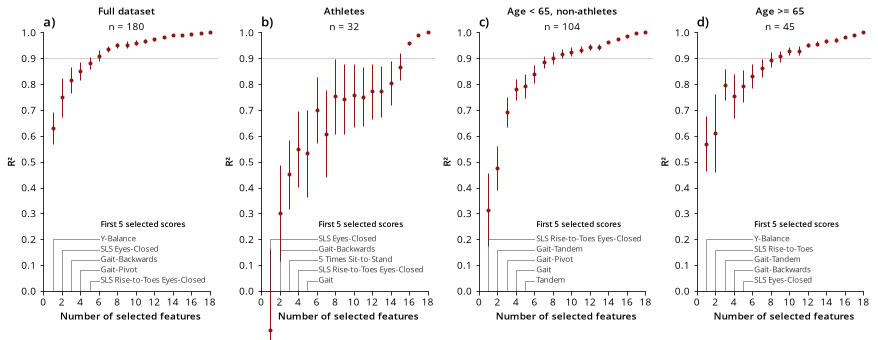

In [5]:
df_subsets = [
    (df, 'Full dataset'),
    (df[df.athlete_current], 'Athletes'),
    (df[(~df.athlete_current)&(df.age<65)], 'Age < 65, non-athletes'),
    (df[df.age>=65], 'Age >= 65'),
]

# fig, axs = plt.subplots(ncols=len(df_subsets), figsize=(12,7))
fig, axs = plt.subplots(ncols=len(df_subsets), figsize=(12,4.5))
for (df_subset, subset_name), ax, subfig_letter in zip(df_subsets, axs, 'abcd'):
    
    df_temp = df_subset[list(ps_cols) + ['stable_score']]
    design = MS(df_temp.columns.drop('stable_score')).fit(df_temp)
    Y = np.array(df_temp['stable_score'])
    X = design.transform(df_temp)
        
    full_path, Yhat_in, feat_order = forward_stepwise_selection(X, Y)

    means = plot_kfold_cv(X, Y, Yhat_in, full_path, ax)
    ax.set_title(f'{subfig_letter})', loc='left', fontdict={'weight':'semibold', 'size':13})
    ax.text(9, 1.06, f'{subset_name}', ha='center', va='bottom', fontdict={'weight':'semibold'})
    ax.text(9, 1, f'n = {len(df_subset)}', ha='center', va='bottom')

    ax.text(6.2, 0.2+0.2/5, 'First 5 selected scores', fontdict={'weight':'semibold', 'size':8}, ha='left', va='bottom')
    for i, feat in enumerate(feat_order[:5]):
        feat_name = ' '.join(ps_cols_labels[feat].split())
        feat_name = feat_name.replace('Single-Leg-Stance', 'SLS')
        ax.text(6.2, 0.2-i*0.2/5, f'{feat_name}', fontdict={'size':8}, color='#383838', ha='left', va='center')
        ax.plot([i+1, i+1, 6], [0, 0.2-i*0.2/5, 0.2-i*0.2/5], c='#383838', alpha=0.5, clip_on=False)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0.0, 1.1, 0.1))

    ax.axhline(0.9, c='#d0d0d0', zorder=-1)
    ax.axhline(0.0, c='#d0d0d0', zorder=-1)
    ax.set_xticks(np.arange(0, 19, 2))
    ax.set_ylabel('R²')

    sns.despine(trim=True)

    print(f'{subset_name} (n = {len(df_subset)})')
    for i, feat in enumerate(feat_order):
        print(f'{i+1:02d} - {means[i]*100:0.1f}% variance - {feat_order[i]}')
    print()

plt.tight_layout(pad=0, w_pad=0)
plt.savefig(figdir / 'fig6.pdf', transparent=True)
plt.show()


In [6]:
print('StaBLE score descriptive statistics for each group')

print('\nAll')
print(df.stable_score.agg(['count', 'mean', 'std']))

print('\nAthletes')
print(df[df.athlete_current].stable_score.agg(['count', 'mean', 'std']))

print('\nAdults < 65 (non-athlete)')
print(df[(~df.athlete_current) & (df.age<65)].stable_score.agg(['count', 'mean', 'std']))

print('\nAdults >= 65')
print(df[df.age>=65].stable_score.agg(['count', 'mean', 'std']))

StaBLE score descriptive statistics for each group

All
count    180.000000
mean       0.637064
std        0.119791
Name: stable_score, dtype: float64

Athletes
count    32.000000
mean      0.709092
std       0.074472
Name: stable_score, dtype: float64

Adults < 65 (non-athlete)
count    104.000000
mean       0.672972
std        0.082954
Name: stable_score, dtype: float64

Adults >= 65
count    45.000000
mean      0.497894
std       0.113431
Name: stable_score, dtype: float64
